In [ ]:
import warnings
import os
import pandas as pd
import re
import numpy as np
from tqdm import tqdm
from llama_cpp import Llama, GGML_TYPE_Q4_0

# 1. 設定區
# ==========================================
MODEL_PATH = r"models\Mistral-Nemo-Instruct-2407-Q4_K_M.gguf"
CSV_PATH   = r"data\raw\fed_transcripts_structured_pycharm.csv"
OUT_CSV    = r"data\processed\FOMC_Analysis_DirectionLocked.csv"

N_ROUNDS = 5 
N_CTX = 32768
N_GPU_LAYERS = -1

# 2. 準備工作
# ==========================================
warnings.filterwarnings("ignore")

print(f"正在載入模型...")
if not os.path.exists(MODEL_PATH) or not os.path.exists(CSV_PATH):
    print("❌ 檔案找不到！"); exit()

try:
    llm = Llama(
        model_path=MODEL_PATH,
        n_ctx=N_CTX, n_gpu_layers=N_GPU_LAYERS,
        flash_attn=True, type_k=GGML_TYPE_Q4_0, type_v=GGML_TYPE_Q4_0, verbose=False
    )
    print("✅ 模型載入成功！")
except Exception as e:
    print(f"❌ 模型初始化失敗：{e}"); exit()

# 3. 核心邏輯函數
# ==========================================
SYSTEM_PROMPT = """You are a Fed Analyst. Analyze the text based ONLY on the provided content.

**Step 1: Identify Key Phrases**
- Find phrases related to "Inflation" (High/Low?)
- Find phrases related to "Employment" (Strong/Weak?)
- Find policy actions (Raise/Cut/Hold?)

**Step 2: Determine Policy Urgency (The Rubric)**
- **Extreme Hawkish (9)**: The Fed expresses a willingness to accept economic pain (recession) to crush high inflation. Priority is solely on price stability.
- **Extreme Dovish (9)**: The Fed expresses a willingness to ignore inflation risks to save the economy from collapse. Priority is solely on employment/growth.
- **Neutral (0)**: Risks are balanced, or the policy is in a "wait-and-see" mode.

**Step 3: Assign Scores (0-10)**
Based on the urgency identified in Step 2, assign a score.
- Hawkish Intensity (0-10)
- Dovish Intensity (0-10)

**Output Format:**
Thinking Process: ...
Hawkish: [0-10]
Dovish: [0-10]"""

def get_hard_constraint(text):
    t = text.lower()
    # 這裡的關鍵字非常準確，是用來做「方向鎖定」的錨點
    if any(k in t for k in ["raised the target range", "increase the target range", "inflation remains elevated"]): return 'positive'
    if any(k in t for k in ["lower the target range", "maintain the target range at 0", "support the flow of credit"]): return 'negative'
    return None

def parse_score(text):
    try:
        h = re.search(r"Hawkish.*?:.*?(\d+)", text, re.IGNORECASE)
        d = re.search(r"Dovish.*?:.*?(\d+)", text, re.IGNORECASE)
        if h and d: return min(int(h.group(1)), 10), min(int(d.group(1)), 10)
    except: pass
    return None, None

# 4. 主程式迴圈
# ==========================================
print("讀取 CSV 資料中...")
df = pd.read_csv(CSV_PATH)
df['Date'] = pd.to_datetime(df['Date'])
df = df.sort_values('Date')

results = []
print(f"開始分析 {len(df)} 場會議 (模式：方向鎖定 + 數值保留)...")
print("-" * 60)

for index, row in tqdm(df.iterrows(), total=len(df)):
    date_str = row['Date'].strftime('%Y-%m-%d')
    text = str(row['Text'])[:15000] # 截取前 15000 字
    
    # [Step A] 抓取硬性約束 (方向)
    constraint = get_hard_constraint(text[:5000]) 
    
    # [Step B] 即使有約束，也強制跑 LLM (為了取得細微數值)
    prompt = f"Date: {date_str}\nText:\n'''\n{text}\n'''\n\nAnalyze."
    round_scores = []
    
    for _ in range(N_ROUNDS):
        try:
            out = llm.create_chat_completion(
                messages=[{"role":"system","content":SYSTEM_PROMPT}, {"role":"user","content":prompt}],
                max_tokens=600, temperature=0.7
            )
            h, d = parse_score(out['choices'][0]['message']['content'])
            
            if h is not None and d is not None:
                # 原始分數 (-1.0 ~ 1.0)
                raw_score = (h - d) / 10.0
                final_round_score = raw_score

                # [Step C] 方向校正 (Directional Correction)
                if constraint == 'positive':
                    # 規則說是鷹派，但模型如果算出負分(鴿派)或太低
                    # 我們強制把它拉回至少 0.5 分 (你可以把 0.5 改成 0.3 或 0.8，看你定義多嚴格)
                    if raw_score < 0.1: 
                        final_round_score = max(raw_score, 0.5) 
                        # 邏輯：如果 raw_score 是 -0.8，取 max(-0.8, 0.5) 變成 0.5 (修正錯誤)
                        # 邏輯：如果 raw_score 是 0.9，取 max(0.9, 0.5) 變成 0.9 (保留高分)

                elif constraint == 'negative':
                    # 規則說是鴿派，模型如果算出正分(鷹派)
                    if raw_score > -0.1:
                        final_round_score = min(raw_score, -0.5)
                        # 邏輯：如果 raw_score 是 0.8，取 min(0.8, -0.5) 變成 -0.5 (修正錯誤)
                        # 邏輯：如果 raw_score 是 -0.9，取 min(-0.9, -0.5) 變成 -0.9 (保留低分)

                round_scores.append(final_round_score)
            else:
                round_scores.append(np.nan)
        except: 
            round_scores.append(np.nan)

    # [Step D] 統計結果
    if round_scores and not np.all(np.isnan(round_scores)):
        final_avg = np.nanmean(round_scores)
        final_std = np.nanstd(round_scores)
        note = "Corrected" if constraint else "Model"
    else:
        final_avg = 0.0
        final_std = 0.0
        note = "Failed"

    results.append({
        "Date": date_str,
        "Score": round(final_avg, 3),
        "Std": round(final_std, 3),
        "Logic": note
    })

    if index % 5 == 0:
        tqdm.write(f" -> {date_str} : Score {final_avg:.2f} ({note})")

# 5. 存檔
# ==========================================
pd.DataFrame(results).to_csv(OUT_CSV, index=False)
print("\n" + "="*60)
print(f"✅ 分析完成！檔案已儲存至：\n{OUT_CSV}")

正在載入模型...


llama_new_context_with_model: n_ctx_per_seq (32768) < n_ctx_train (1024000) -- the full capacity of the model will not be utilized


✅ 模型載入成功！
讀取 CSV 資料中...
開始分析 76 場會議 (模式：方向鎖定 + 數值保留)...
------------------------------------------------------------


  1%|▏         | 1/76 [00:57<1:11:49, 57.46s/it]

 -> 2011-04-27 : Score -0.40 (Model)


...

 -> 2023-12-13 : Score 0.16 (Model)


 93%|█████████▎| 71/76 [56:05<03:40, 44.17s/it]

 -> 2025-03-19 : Score -0.06 (Model)


100%|██████████| 76/76 [59:42<00:00, 47.14s/it]

 -> 2025-10-29 : Score -0.28 (Corrected)

✅ 分析完成！檔案已儲存至：
C:\Users\user\Desktop\llmcourse\FOMC_Analysis_DirectionLocked.csv


正在讀取數據並繪圖...
✅ 繪圖完成！請查看視窗。


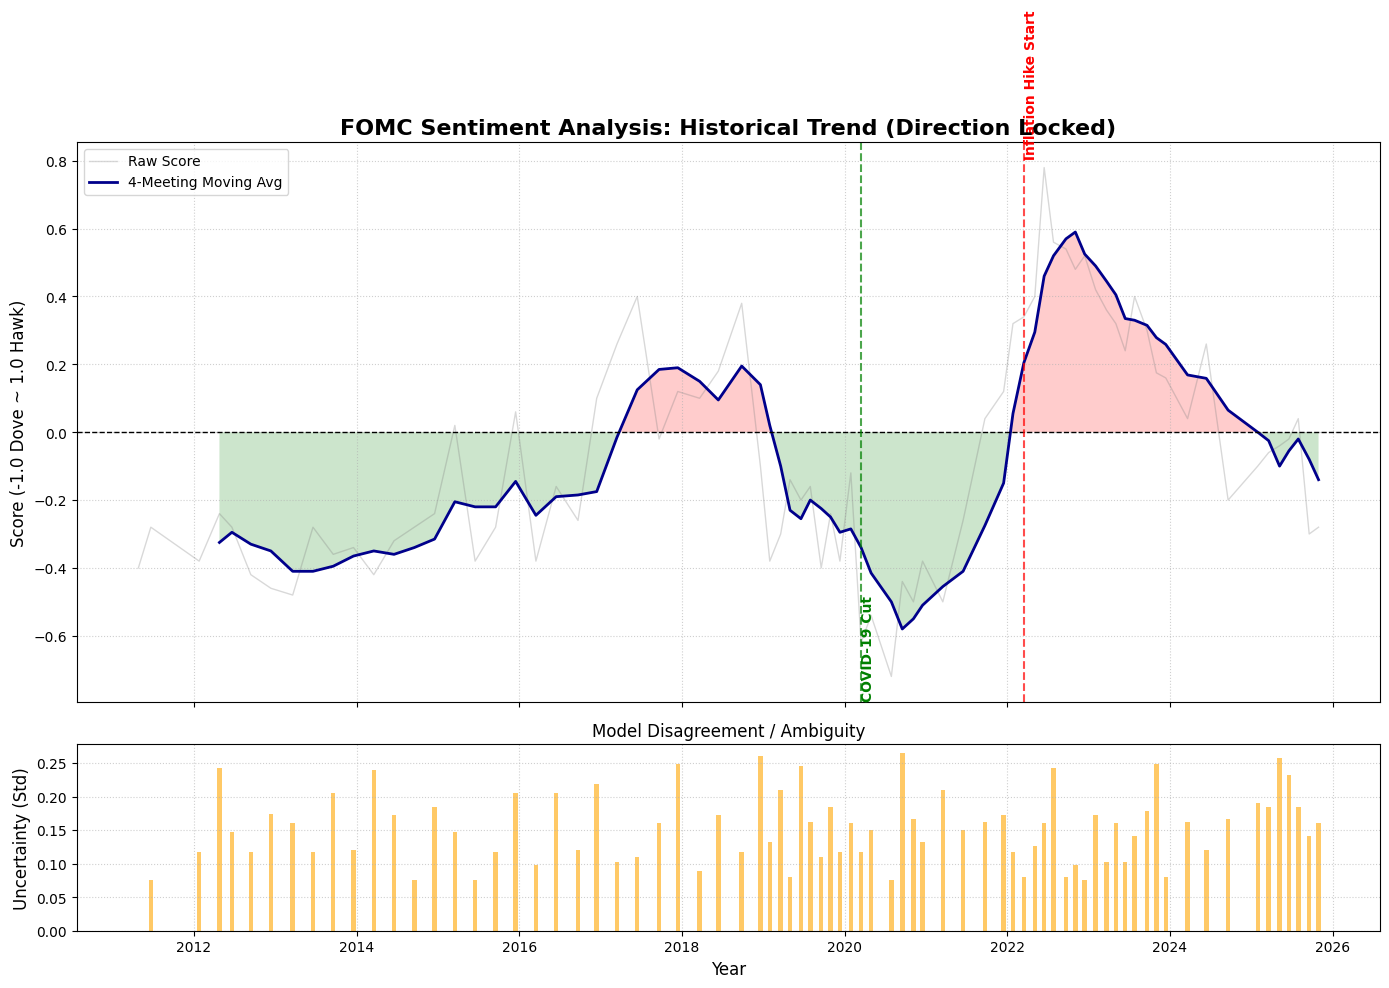

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.dates as mdates

# ================= 設定區 =================
# 請指向你剛剛跑完的那個 CSV 檔案
CSV_PATH =r"data\processed\FOMC_Analysis_DirectionLocked.csv"

# ================= 繪圖邏輯 =================
print("正在讀取數據並繪圖...")
df = pd.read_csv(CSV_PATH)
df['Date'] = pd.to_datetime(df['Date'])
df = df.sort_values('Date')

# 計算移動平均線 (Rolling Average)，讓趨勢更明顯
# window=4 代表約半年的趨勢 (因為 FOMC 一年開 8 次會)
df['MA_4'] = df['Score'].rolling(window=4).mean()

# 設定畫布大小
fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(14, 10), sharex=True, gridspec_kw={'height_ratios': [3, 1]})

# --- 上圖：情緒分數 (Sentiment Score) ---
# 畫原始分數 (淡色)
ax1.plot(df['Date'], df['Score'], color='gray', alpha=0.3, label='Raw Score', linewidth=1)
# 畫移動平均 (深色)
ax1.plot(df['Date'], df['MA_4'], color='darkblue', linewidth=2, label='4-Meeting Moving Avg')

# 填充顏色：大於0是紅色(鷹派)，小於0是綠色(鴿派)
ax1.fill_between(df['Date'], df['MA_4'], 0, where=(df['MA_4'] >= 0), facecolor='red', alpha=0.2, interpolate=True)
ax1.fill_between(df['Date'], df['MA_4'], 0, where=(df['MA_4'] < 0), facecolor='green', alpha=0.2, interpolate=True)

# 畫一條 0 的基準線
ax1.axhline(0, color='black', linewidth=1, linestyle='--')

# 標註重要歷史事件 (用來驗證模型準不準)
events = [
    ('2008-09-15', 'Lehman Collapse', 'green'),
    ('2020-03-15', 'COVID-19 Cut', 'green'),
    ('2022-03-16', 'Inflation Hike Start', 'red')
]

for date_str, label, color in events:
    event_date = pd.to_datetime(date_str)
    if df['Date'].min() <= event_date <= df['Date'].max():
        ax1.axvline(event_date, color=color, linestyle='--', alpha=0.7)
        ax1.text(event_date, 0.8 if color == 'red' else -0.8, f' {label}', color=color, fontweight='bold', rotation=90)

ax1.set_ylabel('Score (-1.0 Dove ~ 1.0 Hawk)', fontsize=12)
ax1.set_title('FOMC Sentiment Analysis: Historical Trend (Direction Locked)', fontsize=16, fontweight='bold')
ax1.legend(loc='upper left')
ax1.grid(True, linestyle=':', alpha=0.6)

# --- 下圖：模型不確定性 (Standard Deviation) ---
ax2.bar(df['Date'], df['Std'], color='orange', alpha=0.6, width=20, label='Model Uncertainty (Std)')
ax2.set_ylabel('Uncertainty (Std)', fontsize=12)
ax2.set_title('Model Disagreement / Ambiguity', fontsize=12)
ax2.grid(True, linestyle=':', alpha=0.6)

# --- 格式整理 ---
plt.xlabel('Year', fontsize=12)
plt.tight_layout()

# 顯示圖片
print("✅ 繪圖完成！請查看視窗。")
plt.show()